In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [3]:
!pip install prophet


   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   --- ------------------------------------ 1.0/12.1 MB 6.2 MB/s eta 0:00:02
   ------ --------------------------------- 1.8/12.1 MB 4.7 MB/s eta 0:00:03
   -------- ------------------------------- 2.6/12.1 MB 4.3 MB/s eta 0:00:03
   ------------ --------------------------- 3.7/12.1 MB 4.2 MB/s eta 0:00:03
   -------------- ------------------------- 4.5/12.1 MB 4.1 MB/s eta 0:00:02
   ----------------- ---------------------- 5.2/12.1 MB 4.1 MB/s eta 0:00:02
   ------------------- -------------------- 6.0/12.1 MB 4.1 MB/s eta 0:00:02
   ---------------------- ----------------- 6.8/12.1 MB 4.0 MB/s eta 0:00:02
   ------------------------ --------------- 7.3/12.1 MB 3.8 MB/s eta 0:00:02
   ---------------------------- ----------- 8.7/12.1 MB 4.0 MB/s eta 0:00:01
   ------------------------------- -------- 9.4/12.1 MB 4.0 MB/s eta 0:00:01
   --------------------------------- ------ 10.2/12.1 MB 4.0 MB/s eta 0:00:01
   --

In [2]:
# Load cleaned dataset
df = pd.read_csv("cleaned_fx_data.csv")

# Rename date column
df.rename(columns={"Unnamed: 0": "ds"}, inplace=True)

# Convert date
df["ds"] = pd.to_datetime(df["ds"])

# Prophet requires column name 'y'
df["y"] = df["USD"]

# Keep only required columns
prophet_df = df[["ds", "y"]]

# Sort (safety)
prophet_df = prophet_df.sort_values("ds")
print(prophet_df)


             ds        y
0    2016-01-01  66.1780
1    2016-01-02  66.1780
2    2016-01-03  66.1780
3    2016-01-04  66.4623
4    2016-01-05  66.5418
...         ...      ...
3649 2025-12-28  89.8296
3650 2025-12-29  89.9756
3651 2025-12-30  89.9429
3652 2025-12-31  89.9198
3653 2026-01-01  89.9792

[3654 rows x 2 columns]


In [3]:
model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True
)

model.fit(prophet_df)


20:38:17 - cmdstanpy - INFO - Chain [1] start processing
20:38:22 - cmdstanpy - INFO - Chain [1] done processing


In [4]:
future_7 = model.make_future_dataframe(periods=7)
forecast_7 = model.predict(future_7)


20:38:27 - cmdstanpy - INFO - Chain [1] start processing
20:38:28 - cmdstanpy - INFO - Chain [1] done processing


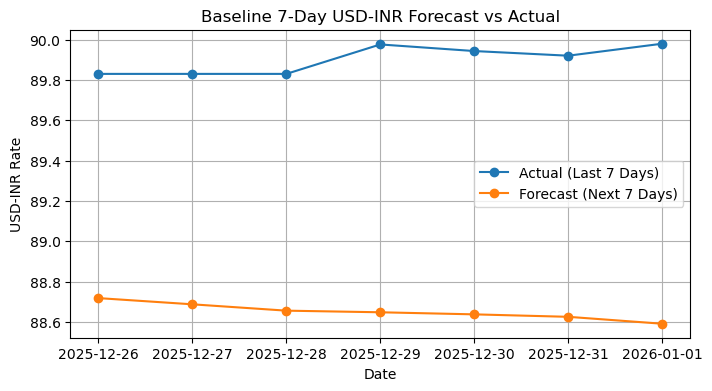

In [5]:
# Take last 7 days as "actual"
actual_last_7 = prophet_df.tail(7)

# Train on data excluding last 7 days
train_baseline = prophet_df.iloc[:-7]

baseline_model = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True
)
baseline_model.fit(train_baseline)

# Forecast next 7 days
future_7 = baseline_model.make_future_dataframe(periods=7)
forecast_7 = baseline_model.predict(future_7).tail(7)

# Plot actual vs forecast
plt.figure(figsize=(8,4))
plt.plot(actual_last_7["ds"], actual_last_7["y"], label="Actual (Last 7 Days)", marker="o")
plt.plot(forecast_7["ds"], forecast_7["yhat"], label="Forecast (Next 7 Days)", marker="o")
plt.xlabel("Date")
plt.ylabel("USD-INR Rate")
plt.title("Baseline 7-Day USD-INR Forecast vs Actual")
plt.legend()
plt.grid()
plt.savefig(
    "Baseline_7Day_USD-INR Forecast vs Actual.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [11]:
future_30 = model.make_future_dataframe(periods=30)
forecast_30 = model.predict(future_30)


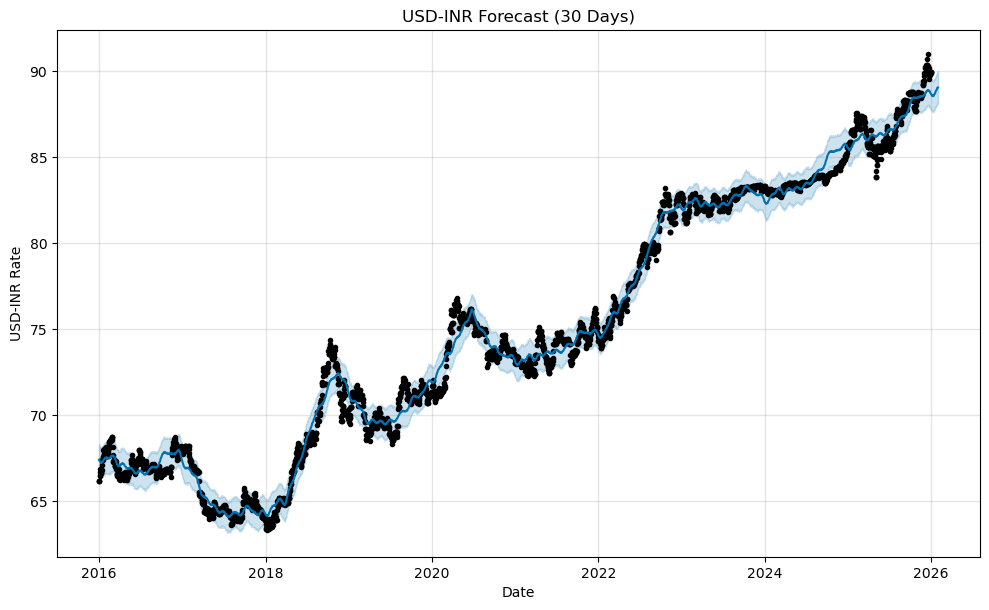

In [24]:
import matplotlib.pyplot as plt

model.plot(forecast_30)
plt.title("USD-INR Forecast (30 Days)")
plt.xlabel("Date")
plt.ylabel("USD-INR Rate")

plt.savefig(
    "usd_inr_30day_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [15]:
train = prophet_df.iloc[:-14]
test = prophet_df.iloc[-14:]
bt_model = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True
)

bt_model.fit(train)


19:40:00 - cmdstanpy - INFO - Chain [1] start processing
19:40:02 - cmdstanpy - INFO - Chain [1] done processing


In [16]:
future_bt = bt_model.make_future_dataframe(periods=14)
forecast_bt = bt_model.predict(future_bt)

# Extract predicted values
predicted = forecast_bt.tail(14)["yhat"].values
actual = test["y"].values


In [17]:
mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))

print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))


MAE: 1.3162
RMSE: 1.3295


In [19]:
future_forecast = forecast_30.tail(30)
neutral_case = future_forecast["yhat"].mean()
optimistic_case = future_forecast["yhat_lower"].mean()
pessimistic_case = future_forecast["yhat_upper"].mean()

print("Optimistic (INR strengthens):", round(optimistic_case, 2))
print("Neutral Scenario:", round(neutral_case, 2))
print("Pessimistic (INR weakens):", round(pessimistic_case, 2))


Optimistic (INR strengthens): 87.87
Neutral Scenario: 88.76
Pessimistic (INR weakens): 89.65
